# Python visualization library

This script demonstrates how to draw elemental plots in python with different libraries. It's up to you to decide which one you prefer!

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
from plotly import __version__
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import plotly.express as px
print(__version__) # requires version >= 1.9.0
# For Notebooks
init_notebook_mode(connected=True)

5.9.0


In [ ]:
#import cufflinks as cf
#cf.go_offline()

ModuleNotFoundError: No module named 'cufflinks'

In [5]:
# get a basic dataset to play with
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Scatterplot

### Matplotlib

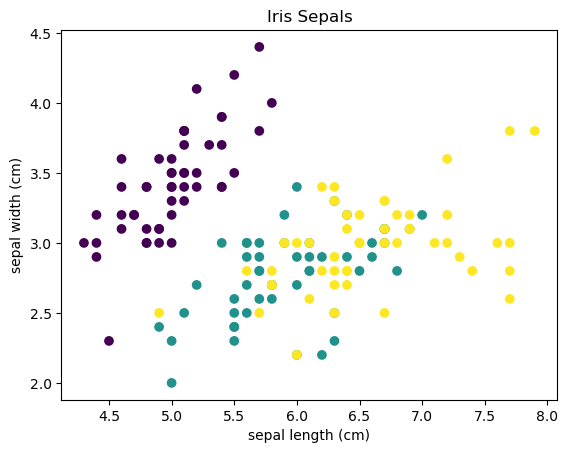

In [6]:
# basic version
plt.scatter(df['sepal_length'], df['sepal_width'], c=df['species'].astype('category').cat.codes)
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.title("Iris Sepals")
plt.show()

Text(0.5, 1.0, 'Iris Sepals')

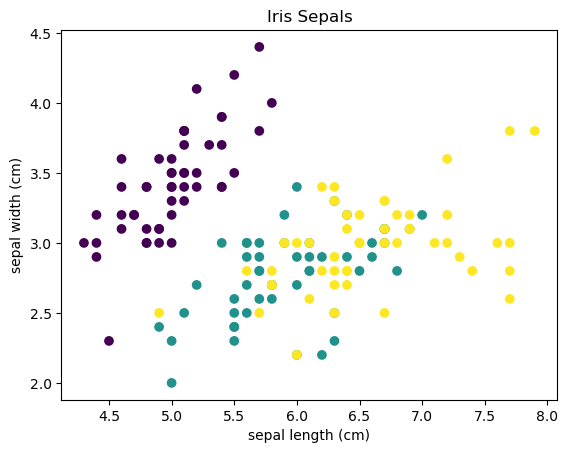

In [36]:
# OO version
fig, ax = plt.subplots()
ax.scatter(df['sepal_length'], df['sepal_width'], marker = 'o', c=df['species'].astype('category').cat.codes) # awkward color definition. Providing arrays instead of the column and the data source might be  abonus or malus. I feel it might be easier to work with data structures not native to pandas
ax.set_xlabel('sepal length (cm)') # Why oh why does the syntax change?
ax.set_ylabel('sepal width (cm)')
ax.set_title('Iris Sepals')

### Seaborn

Text(0.5, 1.0, 'Iris Sepals')

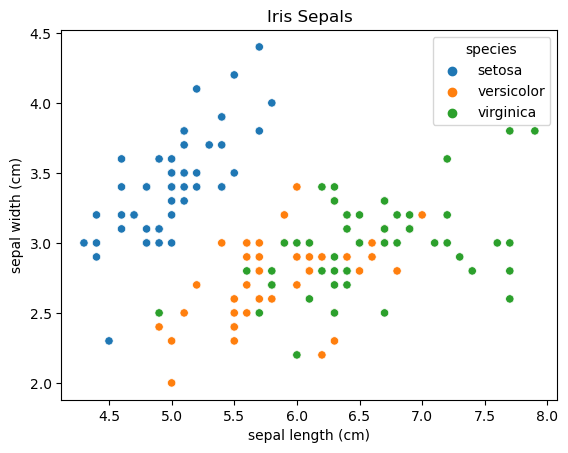

In [ ]:
p = sns.scatterplot(data = df, x = 'sepal_length', y = 'sepal_width', hue = 'species') # coming from R, this feels most natural, by defining the dataset and the columns to plot
p.set_xlabel('sepal length (cm)') # at least consistent with advanced matplotlib
p.set_ylabel('sepal width (cm)')
p.set_title('Iris Sepals')

### Pandas

Text(0.5, 1.0, 'Iris Sepals')

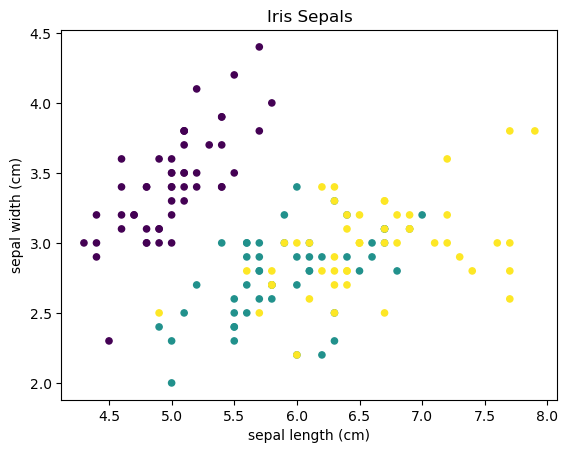

In [ ]:
# requires an addional argumeent to drop the colorbar
pp = df.plot.scatter(x = 'sepal_length', y = 'sepal_width',   c = df['species'].astype('category').cat.codes, cmap = 'viridis', colorbar=False)
pp.set_xlabel('sepal length (cm)') # consistent with advanced matplotlib
pp.set_ylabel('sepal width (cm)')
pp.set_title('Iris Sepals')

### Plotly

In [10]:
fig = px.scatter(df, x="sepal_width", y="sepal_length", color="species", title="Iris Sepals", labels={"sepal_width": "sepal width (cm)", "sepal_length": "sepal length (cm)"})
# assign axis labels
fig.update_layout(xaxis_title="Sepal Width (cm)", yaxis_title="Sepal Length (cm)") # If you forget to use the dictionary in labels, you can still do it here
# show the figure
fig.show()

## Histogram

### Matplotlib

Text(0.5, 1.0, 'Iris Sepal Length')

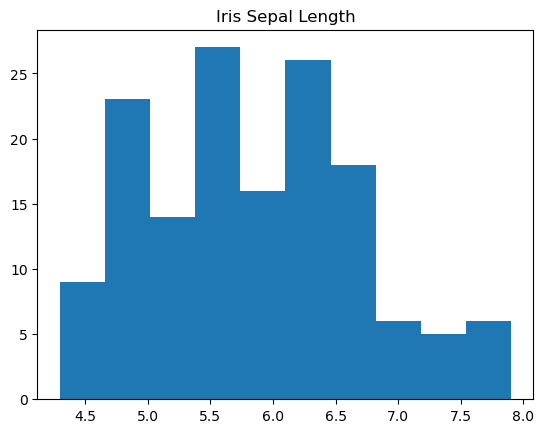

In [19]:
plt.hist(df['sepal_length'])
plt.title('Iris Sepal Length')

Text(0.5, 1.0, 'Iris Sepal Length')

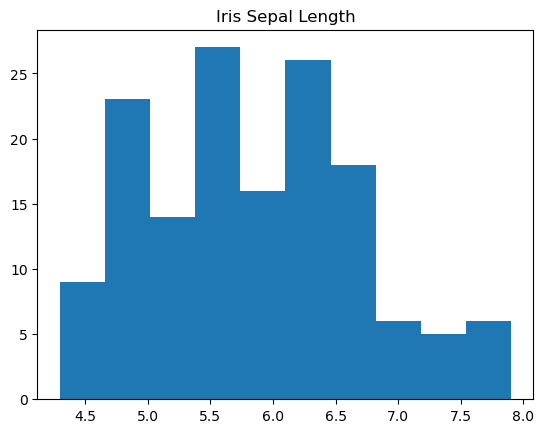

In [34]:
# OO version
fig, ax = plt.subplots()
ax.hist(df['sepal_length'])
ax.set_title('Iris Sepal Length')

### Seaborn

Text(0.5, 1.0, 'Iris Sepal length')

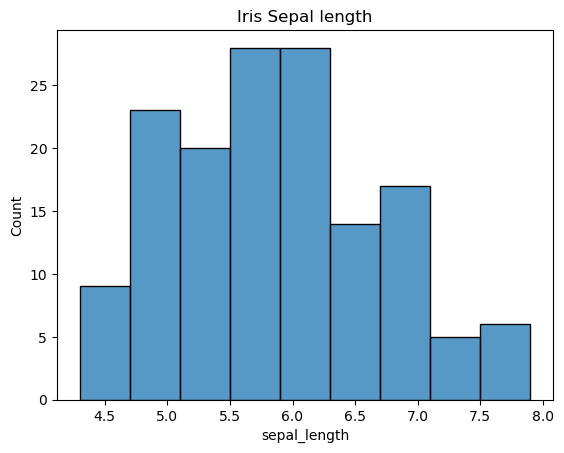

In [22]:
p = sns.histplot(data = df, x = 'sepal_length')
p.set_title('Iris Sepal length')

### Pandas

Text(0.5, 1.0, 'Iris sepal length')

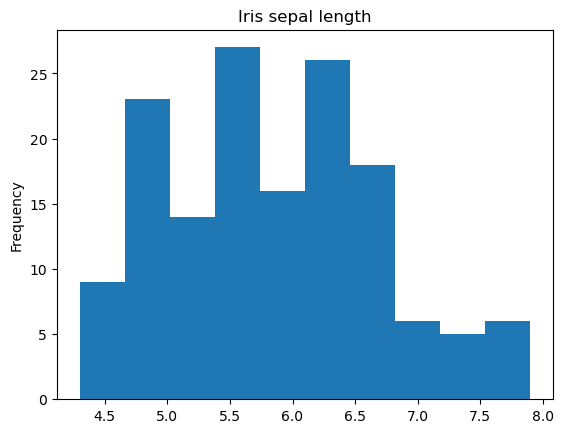

In [24]:
pp = df['sepal_length'].plot.hist() # the IDE automatically suggests the available columns, a feature, missing in sns
pp.set_title('Iris sepal length')

### Plotly

In [11]:
fig = px.histogram(df, x="sepal_length", title="Iris Sepal Length", labels={"sepal_length": "sepal length (cm)"}   )
fig.show()

## Boxplot

### Matplotlib

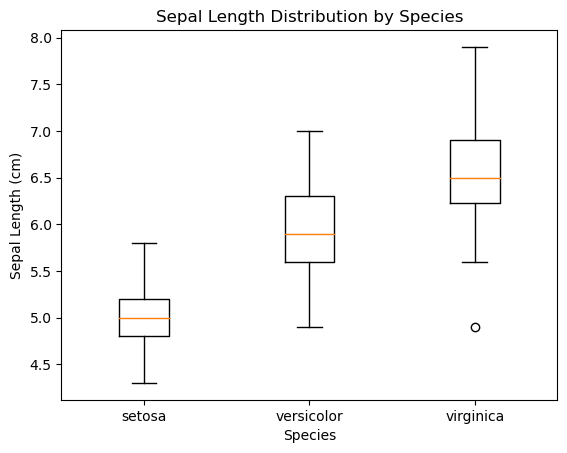

In [31]:

# Prepare data for boxplot grouped by species
data_by_species = [df[df['species'] == species]['sepal_length'] for species in df['species'].unique()]

# Create boxplot
plt.boxplot(data_by_species, labels=df['species'].unique())
plt.xlabel('Species')
plt.ylabel('Sepal Length (cm)')
plt.title('Sepal Length Distribution by Species')
plt.show()


Text(0.5, 1.0, 'Iris Sepal Length')

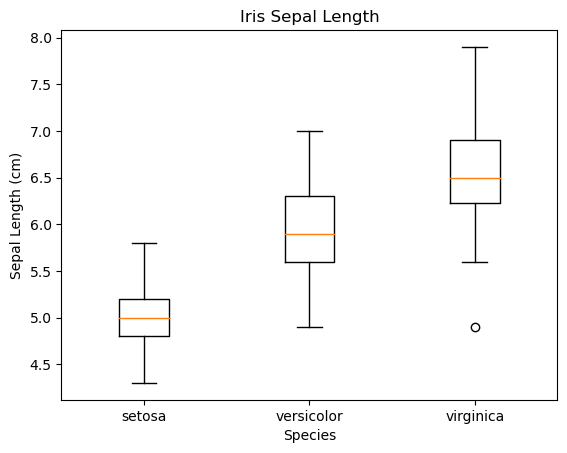

In [40]:
fig, ax = plt.subplots()
ax.boxplot(data_by_species, labels=df['species'].unique())
ax.set_xlabel('Species')
ax.set_ylabel('Sepal Length (cm)')
ax.set_title('Iris Sepal Length')

### Seaborn

Text(0.5, 1.0, 'Iris Sepal length by species')

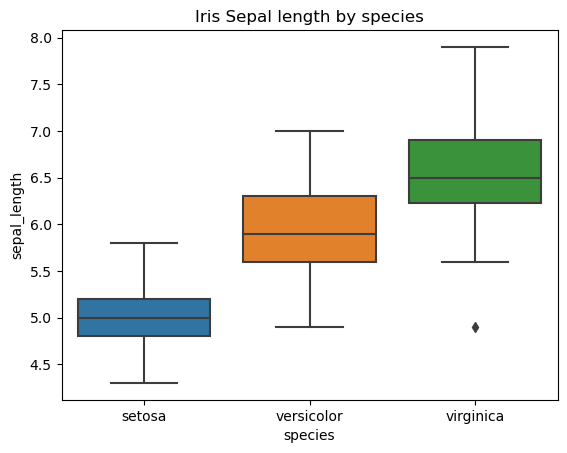

In [ ]:
p = sns.boxplot(data = df, x = 'species', y = 'sepal_length')
p.set_title('Iris Sepal length by species' )

### Pandas

Text(0, 0.5, 'Sepal length')

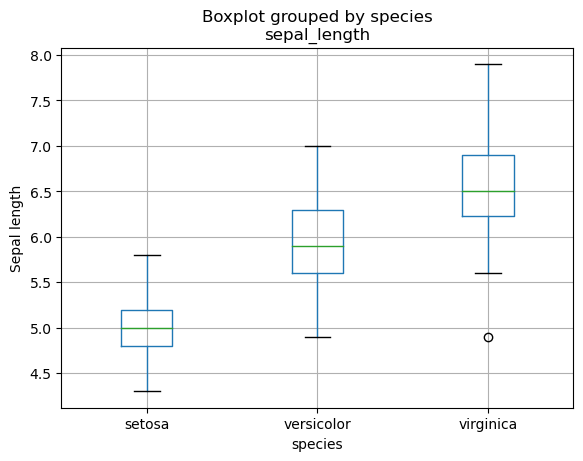

In [ ]:
pp = df.boxplot(column='sepal_length', by='species') # plot label and x_achsis label set automatically
pp.set_ylabel('Sepal length')

### Plotly

In [12]:
fig = px.box(df, x="species", y="sepal_length", title="Iris Sepal Length by Species", labels={"sepal_length": "sepal length (cm)", "species": "species"})
fig.show()

## Essence so far: 
- matplotlib basic is stupid, as it requires a lot of arguments to define the figure and the arguments differ from those in its own OO approcah or other libraries
- matplotlib OO style uses similar arguments as seaborn and pandas (plus), but requires a lot more settings to generate same figures (which is cumbersome)
- seaborn and pandas are ~au par regarding ease of use. Coming from R, seaborn feels more natural. 
- pandas has the downside to change function calls depending om plot type (how to define columns to map), which is more stringent in seaborn
- pandas has the advantage to "offering" column selection via IDE, so you don't need to memorize or copy paste column names in the funcction but get them automatically via IDE suggestions. Can be a bonus if you just want to get a quick overview and you are not aiming at publication-ready visuals
- plotly is surprisingly intuitive. However, uses own syntax. Can be overwhelming, but possibly the largest benefit to learn, as html ready

## Further reading

* http://www.matplotlib.org - The project web page for matplotlib.
* http://matplotlib.org/gallery.html - A large gallery showcaseing various types of plots matplotlib can create. Highly recommended! 
* http://www.loria.fr/~rougier/teaching/matplotlib - A good matplotlib tutorial, also good as quick reference for basic stuff
* https://pandas.pydata.org/docs/user_guide/visualization.html - Overview on pandas visualization capabilities
* https://seaborn.pydata.org/index.html - seaborn documentation
* https://plotly.com/python/ - plotly start page